# Multiple FFT

In [103]:
from numpy import fft as fft
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import lmfit
from lmfit.models import GaussianModel, LorentzianModel, LinearModel, ConstantModel
from lmfit import Model
from lmfit import conf_interval, conf_interval2d, report_ci

# find_pulse_end

In [2]:
def find_pulse_end(signal, threshold_max, threshold_min):
  trigger = False
  print(signal[4])
  print(signal)
  for i in range(len(signal)):
    if (signal[i] > threshold_max):
      trigger = True
    if (trigger == True and signal[i] < threshold_min):
      return(i)
  return(0)

# chop_signal

In [3]:
def chop_signal(signal, start):
  return(signal[start:])

# get_fft_from_FID

In [150]:
def get_fft_from_FID(fft_df, threshold_max, threshold_min):
    time = fft_df['time']
    ch1 = fft_df['channel_1']

    fig, ax = plt.subplots()

    # print(type(ch1))

    print("This is the raw FID plot\n")
    plt.plot(time, ch1)
    # plt.show()

    chop_point = find_pulse_end(ch1, threshold_max, threshold_min) 
    chopped_ch1 = chop_signal(ch1,chop_point)
    chopped_time = chop_signal(time, chop_point)

    print("this is the chopped plot\n")

    plt.plot(chopped_time, chopped_ch1)
    plt.show()

    chopped_ch1 = chopped_ch1.tolist()

    # print(chopped_ch1)

    ch1_fft = fft.rfft(chopped_ch1)
    freqs = fft.rfftfreq(len(chopped_ch1), d=time[1]-time[0])


    return freqs, ch1_fft

# txt_fit_report

In [151]:
def txt_fit_report(filename, report):
    with open(filename, "w") as f:
        f.write("Fit Report for Hydrogen Peak in Mineral Oil\n")
        f.write("="*50 + "\n")
        f.write(report)

# plot_FID

# get_filenames

In [152]:

from pathlib import Path

def get_filenames(folder_path, extension=None):
    """
    Returns:
    1. A list of absolute PATHS for the original files.
    2. A list of FILENAMES (strings) for the corresponding [filename]_out.txt.
    """
    path = Path(folder_path).resolve()
    
    if not path.is_dir():
        return [], []

    # Get the source file objects
    if extension:
        files = list(path.glob(f"*{extension}"))
    else:
        files = [f for f in path.iterdir() if f.is_file()]

    # Original paths: Full absolute location
    original_paths = [str(f) for f in files]
    
    # Output names: Just the filename string with the suffix added
    output_names = [f"{f.name}_out.txt" for f in files]

    return original_paths, output_names

# get_fourier_freq

This is the raw FID plot

0.08
0       0.00
1       0.00
2       0.00
3       0.00
4       0.08
        ... 
2494   -0.08
2495    0.00
2496    0.00
2497    0.00
2498    0.00
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



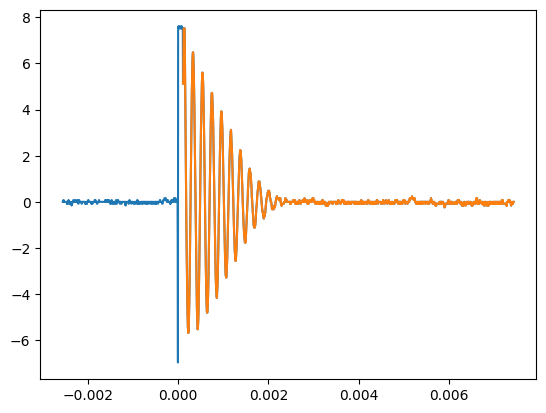

## Confidence Report:
Frequency is at 4786.367581187583 Hz


{'max_freq': 4786.367581187583,
 'max_power': np.float64(765906.4381246517),
 'result': <lmfit.model.ModelResult at 0x1dfe55d9810>,
 'eval': array([-9.12653711e+03, -9.10210683e+03, -9.07753021e+03, -9.05280563e+03,
        -9.02793140e+03, -9.00290584e+03, -8.97772724e+03, -8.95239386e+03,
        -8.92690394e+03, -8.90125569e+03, -8.87544729e+03, -8.84947692e+03,
        -8.82334269e+03, -8.79704272e+03, -8.77057509e+03, -8.74393786e+03,
        -8.71712904e+03, -8.69014663e+03, -8.66298859e+03, -8.63565287e+03,
        -8.60813737e+03, -8.58043996e+03, -8.55255849e+03, -8.52449077e+03,
        -8.49623457e+03, -8.46778765e+03, -8.43914771e+03, -8.41031243e+03,
        -8.38127945e+03, -8.35204638e+03, -8.32261080e+03, -8.29297023e+03,
        -8.26312217e+03, -8.23306409e+03, -8.20279338e+03, -8.17230745e+03,
        -8.14160362e+03, -8.11067919e+03, -8.07953142e+03, -8.04815753e+03,
        -8.01655467e+03, -7.98471998e+03, -7.95265053e+03, -7.92034336e+03,
        -7.88779545e+03,

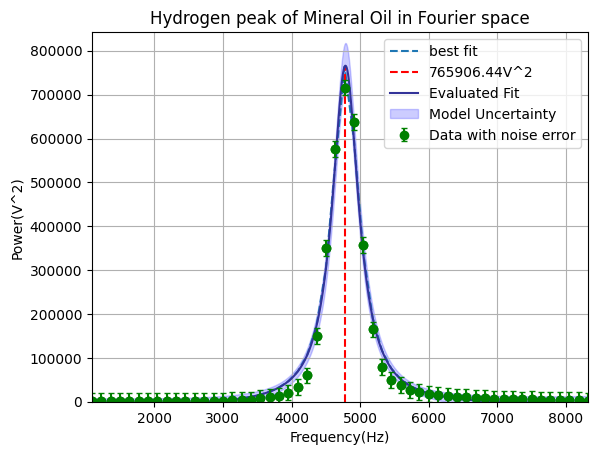

In [153]:
filename = "2.10 Data Sample 2/FIDs/Sample2_FID_freq6487930.csv"
out_filename = "fit_Sample2_FID_freq6485930.txt"
pulse_params= {"threshold_max":7.5, "threshold_min":6}
fft_params = {"initial_sigma": 5000, "num_points": 700, "sigma_levels": [1,2,3]}

def get_fourier_freq(filename, out_filename, pulse_params, fft_params, i_offset=30, plot=True):

    # Read the data into a dataframe

    # print(filename)
    fft_df = pd.DataFrame()
    fft_df = pd.read_csv(filename)
    cols = ['time', 'channel_1','channel_2']
    fft_df.columns = cols
    # fft_t2_df.head()

    # #Plot the FID
    # time = fft_t2_df['time']
    # ch1 = fft_t2_df['channel_1']

    freqs, ch1_fft = get_fft_from_FID(fft_df, pulse_params["threshold_max"], pulse_params["threshold_min"])
    
    

    # # Cut out the pulse
    # chop_point = find_pulse_end(ch1, 
    #                             pulse_params["threshold_max"], 
    #                             pulse_params["threshold_min"]) 
    # chopped_ch1 = chop_signal(ch1,chop_point) 
    # chopped_time = chop_signal(time, chop_point) 

    # if plot==True:
    #     plt.plot(time, ch1)
    #     plt.plot(chopped_time, chopped_ch1)
    #     plt.grid()
    #     plt.show()

    # # chopped_time, chopped_ch1 = plot_FID(filename)

    # # Apply fourier transform
    # print(type(chopped_ch1))

    

    # ch1_fft = fft.rfft(chopped_ch1)
    # freqs = fft.rfftfreq(len(chopped_ch1), d=time[1]-time[0])


    # we are looking at freqs vs power
    power = np.abs(ch1_fft)**2

    # get initial guess of peak and index it occurs at
    
    maxi = np.argmax(power, axis=0)

    raw_points = len(freqs)

    start_i = maxi - int(i_offset*raw_points)
    end_i = maxi + int(i_offset*raw_points)

    if start_i < 0:
        start_i = 0

    power=power[start_i: end_i]
    freqs=freqs[start_i: end_i]

    maxval = np.max(power, axis=0)
    maxi = np.argmax(power, axis=0)


    max_freq = freqs[maxi]



    gmodel = LorentzianModel()+ LinearModel()
    initial_sigma = fft_params['initial_sigma']
    initial_amplitude = maxval * initial_sigma * np.sqrt(2 * np.pi)
    params = gmodel.make_params()
    params['slope'].set(value=-1) # Better guess for constant background
    params['amplitude'].set(value=initial_amplitude, min=0) 
    params['center'].set(value=max_freq, min=0)
    params['sigma'].set(value=initial_sigma, min=1e-3)



    # get the fit
    result = gmodel.fit(power,params, x= freqs)

    # evaluate fit at many freq values

    
    many_freqs = np.linspace(np.min(freqs),np.max(freqs), fft_params['num_points'])
    y_random_fit = result.eval(x=many_freqs)



    # get CIs of all the parameters
    # print(result.fit_report())
    sigma_levels = fft_params['sigma_levels']
    txt_fit_report(out_filename, result.fit_report())
    ci = conf_interval(result, result, sigmas=sigma_levels)


    # using evaluated fit get peak values
    new_maxval = np.max(y_random_fit, axis=0)
    # new_maxi = np.argmax(y_random_fit, axis=0)
    # new_max_freq = many_freqs[new_maxi]

    # new_maxval = result.params['amplitude'].value
    # new_maxi = np.argmax(y_random_fit, axis=0)
    new_max_freq = result.params['center'].value


    

    dely_random = result.eval_uncertainty(x=many_freqs, sigma=3)

    noise_sigma = result.residual.std()

    # plt.show()
    
    # plt.plot(freqs, many_result.best_fit, '-', label='best fit')



    if plot==True:
        plt.scatter(freqs, power, color = "green")
        plt.plot(freqs, result.best_fit, '--', label='best fit')
        plt.title("Hydrogen peak of Mineral Oil in Fourier space")
        plt.xlabel("Frequency(Hz)")
        plt.ylabel("Power(V^2)")
        # plt.plot(freqs, power)
        plt.vlines(new_max_freq, 0, new_maxval,colors="red", linestyles="--", label=f"{new_maxval:.2f}V^2")
        plt.plot(many_freqs, y_random_fit, color=(0.2,0.2,0.6), label='Evaluated Fit')
        # Add the confidence interval for the random points
        plt.fill_between(many_freqs, 
                        y_random_fit - dely_random, 
                        y_random_fit + dely_random, 
                        color="blue", alpha=0.2, label='Model Uncertainty')
        plt.errorbar(freqs, power, yerr=noise_sigma, fmt='o', 
                    color="green", ecolor='green', 
                    capsize=2, label='Data with noise error')
        plt.grid()
        plt.xlim(np.min(freqs), np.max(freqs) )
        plt.ylim(0,new_maxval*(1.1))
        plt.legend()
        
    print("## Confidence Report:")
    # report_ci(ci)

    print(f"Frequency is at {new_max_freq} Hz")

    return {'max_freq':new_max_freq, 'max_power':new_maxval, 'result': result, 'eval': y_random_fit, 'ci': ci}
        
get_fourier_freq(filename, out_filename, pulse_params, fft_params, i_offset=3e-2)      

# get_fft_data

In [154]:
def get_fft_data(sample, sampleout, pulse_params, fft_params, id='', plot=True):
    fft_list = []
    count = 0
    for filename in sample:
        out_filename = "outdata/" + sampleout[count] + id
        fft_data = get_fourier_freq(filename, out_filename, pulse_params, fft_params, i_offset=3e-2, plot=plot)
        # print(fft_data)
        fft_list.append(fft_data)
        count += 1
    return fft_list



# Sample 1

In [158]:
sample1filename = "pNMR 2.26 final data FID/SAMPLE1"
sample1, sample1out = get_filenames(sample1filename, extension='.csv')

# sample1_2filename = "pNMR2.5 FFT T2 data/Sick_aFIDS"
# sample1_2, sample1_2out = get_filenames(sample1_2filename, extension='.csv')

# sample1 = sample1 + sample1_2
# sample1out = sample1out + sample1_2out

# print(sample1)


### first sample 1

This is the raw FID plot

0.0
0       0.06
1       0.06
2       0.00
3       0.00
4       0.00
        ... 
2494    0.00
2495    0.00
2496   -0.06
2497   -0.06
2498   -0.06
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



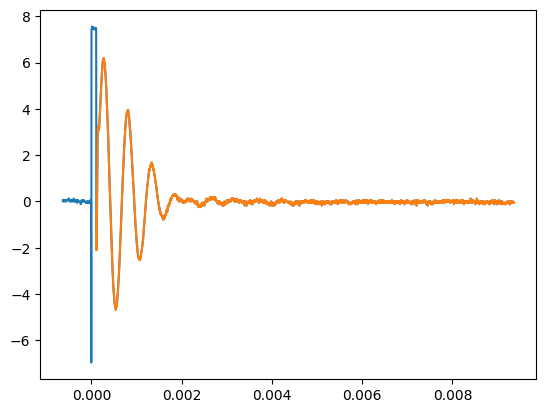

## Confidence Report:
Frequency is at 1816.6926656412513 Hz
This is the raw FID plot

0.06
0       0.06
1       0.00
2       0.00
3       0.00
4       0.06
        ... 
2494    0.00
2495    0.00
2496    0.00
2497    0.00
2498   -0.06
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



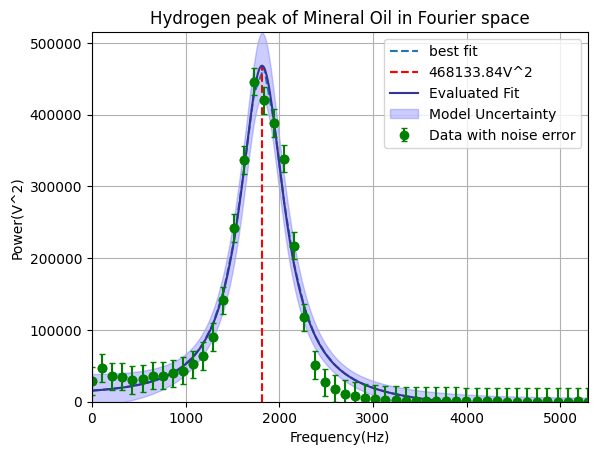

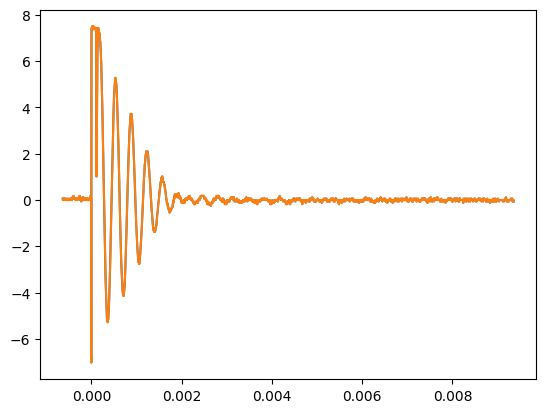

## Confidence Report:
Frequency is at 2706.438045905261 Hz
This is the raw FID plot

0.0
0       0.00
1      -0.06
2      -0.06
3      -0.06
4       0.00
        ... 
2494    0.00
2495    0.00
2496    0.00
2497    0.00
2498   -0.06
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



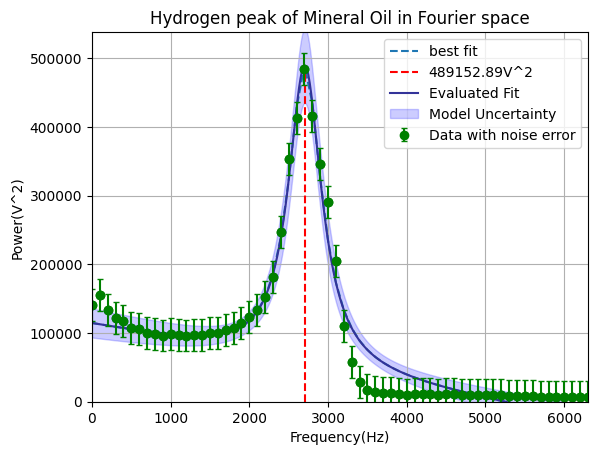

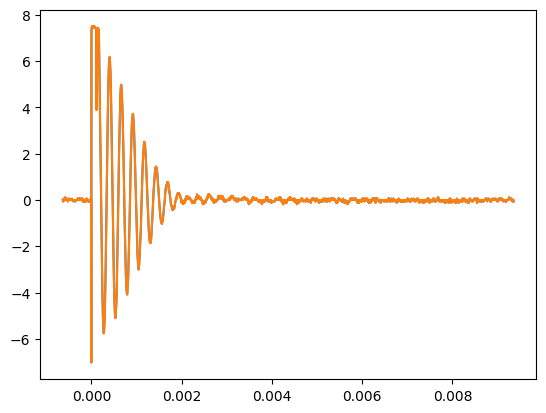

## Confidence Report:
Frequency is at 3764.5967211899206 Hz
This is the raw FID plot

0.0
0       0.00
1       0.00
2       0.00
3       0.00
4       0.00
        ... 
2494    0.00
2495    0.06
2496    0.00
2497    0.00
2498    0.00
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



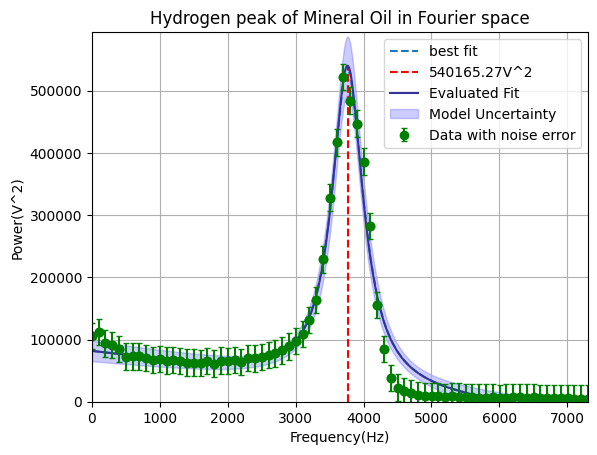

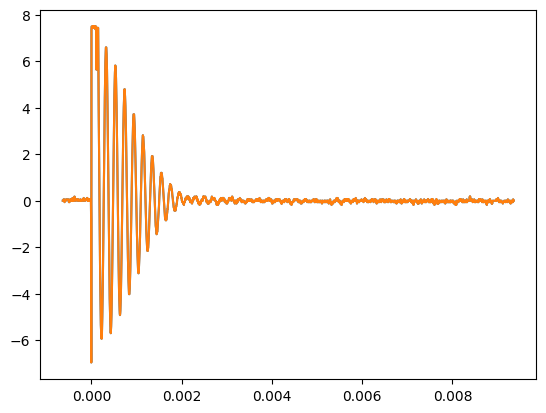

## Confidence Report:
Frequency is at 4809.324767117645 Hz
This is the raw FID plot

0.0
0       0.06
1       0.12
2       0.12
3       0.00
4       0.00
        ... 
2494    0.00
2495   -0.06
2496    0.00
2497    0.00
2498   -0.06
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



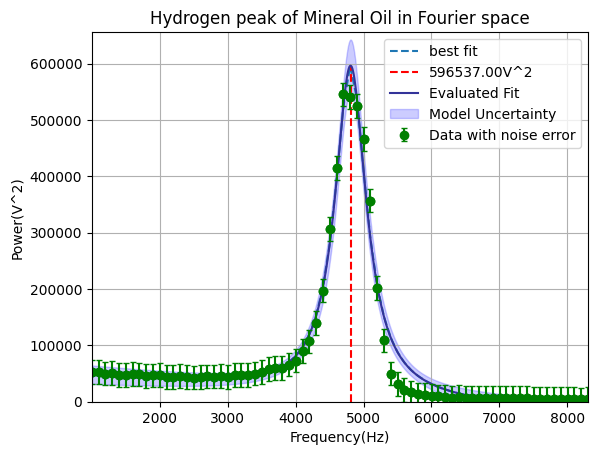

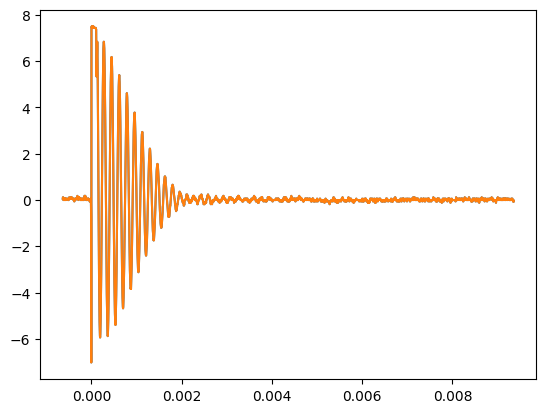

## Confidence Report:
Frequency is at 5838.9577475744245 Hz
This is the raw FID plot

0.06
0       0.06
1       0.06
2       0.06
3       0.12
4       0.06
        ... 
2494   -0.06
2495   -0.06
2496   -0.06
2497   -0.06
2498   -0.06
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



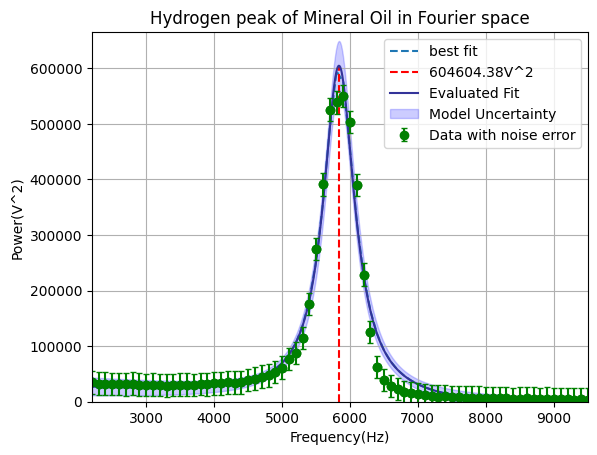

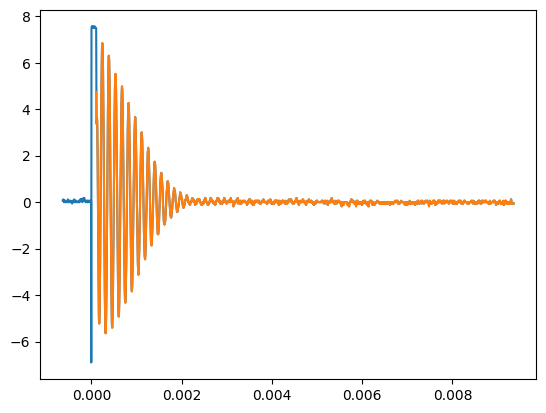

## Confidence Report:
Frequency is at 6902.417200778105 Hz
This is the raw FID plot

0.0
0      -0.06
1      -0.06
2       0.00
3       0.00
4       0.00
        ... 
2494    0.00
2495    0.06
2496    0.06
2497    0.00
2498    0.06
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



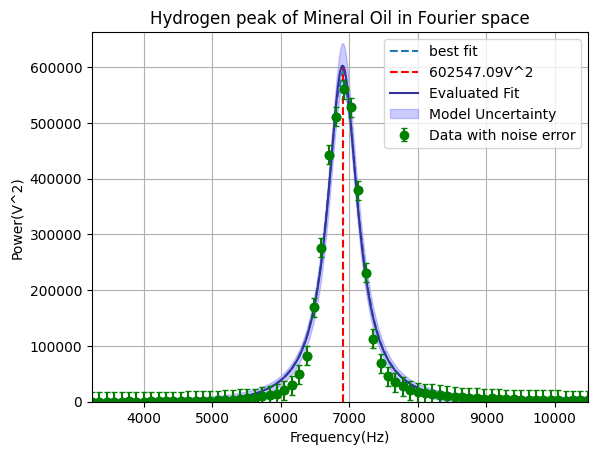

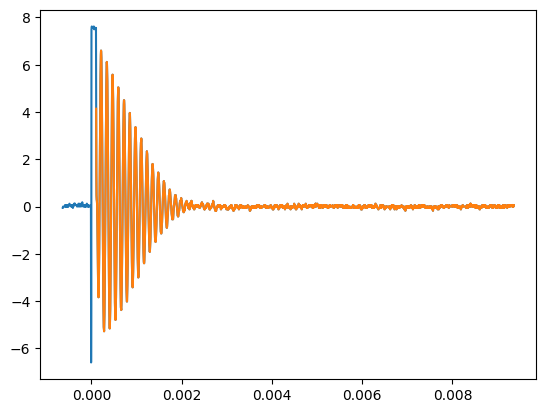

## Confidence Report:
Frequency is at 7890.333782948275 Hz


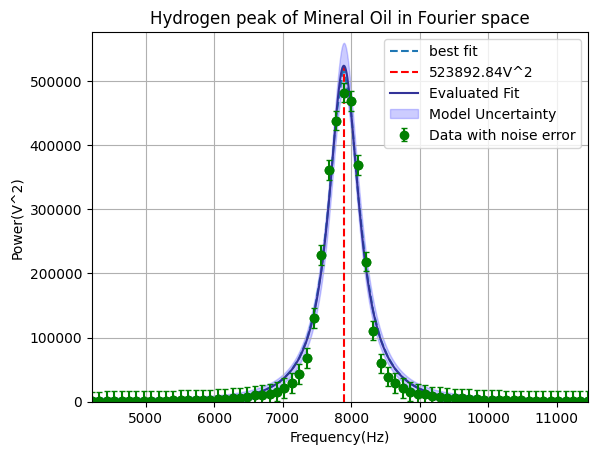

In [159]:

pulse_params= {"threshold_max":7.5, "threshold_min":6.1}
fft_params = {"initial_sigma": 5000, "num_points": 700, "sigma_levels": [1,2,3]}

fft_s1_list = get_fft_data(sample1, sample1out, pulse_params, fft_params, id = '_sample1')

### second sample 1

In [160]:
sample1_2filename = "pNMR2.5 FFT T2 data/Sick_aFIDS"
sample1_2, sample1_2out = get_filenames(sample1_2filename, extension='.csv')

This is the raw FID plot

0.0
0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
2494    0.0
2495    0.0
2496    0.0
2497    0.0
2498    0.0
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



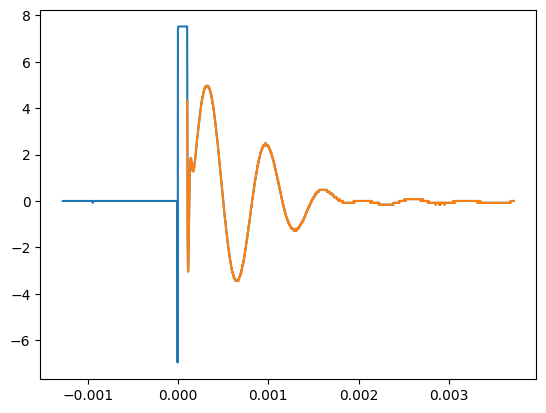

c:\Users\diyan\pNMR\pnmr_analysis\pnmr_env2\Lib\site-packages\lmfit\confidence.py:362: UserWarning: maxiter=200 reached and prob(intercept=-17226.1548881435) = 0.5675704448100456 < max(sigmas)
  warn(errmsg)


## Confidence Report:
Frequency is at 1465.041633085371 Hz
This is the raw FID plot

0.0
0       0.00
1       0.00
2       0.00
3       0.00
4       0.00
        ... 
2494   -0.08
2495   -0.08
2496   -0.08
2497   -0.08
2498   -0.08
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



c:\Users\diyan\pNMR\pnmr_analysis\pnmr_env2\Lib\site-packages\lmfit\confidence.py:362: UserWarning: maxiter=200 reached and prob(intercept=18105.040341620224) = 0.5717892593518052 < max(sigmas)
  warn(errmsg)


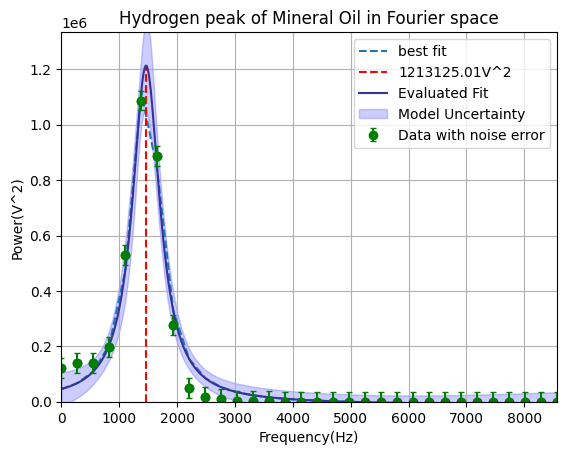

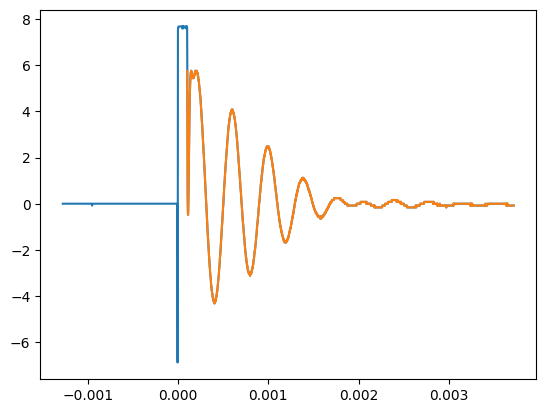

c:\Users\diyan\pNMR\pnmr_analysis\pnmr_env2\Lib\site-packages\lmfit\confidence.py:362: UserWarning: maxiter=200 reached and prob(intercept=-13132.546920046145) = 0.39181703985271876 < max(sigmas)
  warn(errmsg)


## Confidence Report:
Frequency is at 2489.9825854485402 Hz
This is the raw FID plot

0.0
0       0.00
1       0.00
2       0.00
3       0.00
4       0.00
        ... 
2494   -0.08
2495   -0.08
2496    0.00
2497   -0.08
2498   -0.08
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



c:\Users\diyan\pNMR\pnmr_analysis\pnmr_env2\Lib\site-packages\lmfit\confidence.py:362: UserWarning: maxiter=200 reached and prob(intercept=13802.574824130126) = 0.3932499884761011 < max(sigmas)
  warn(errmsg)


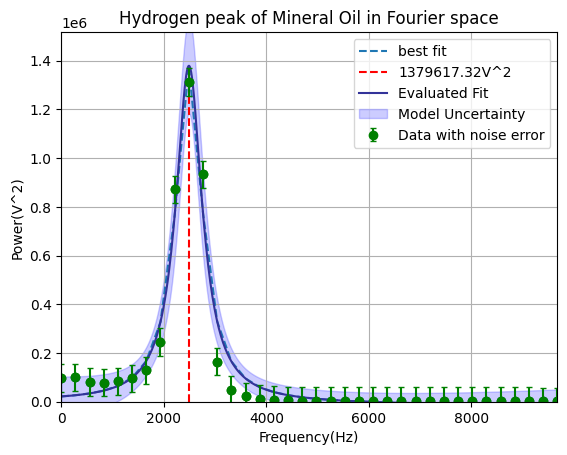

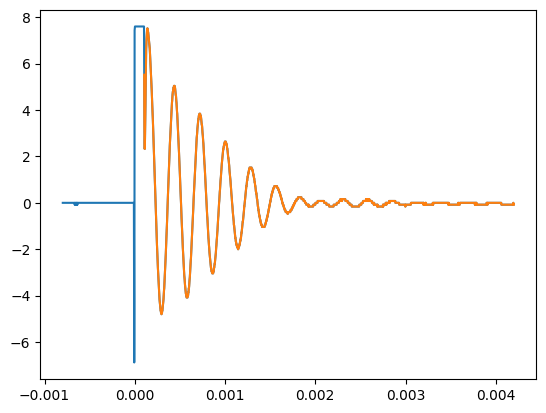

## Confidence Report:
Frequency is at 3535.1428184089436 Hz
This is the raw FID plot

0.0
0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
2494    0.0
2495    0.0
2496    0.0
2497    0.0
2498    0.0
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



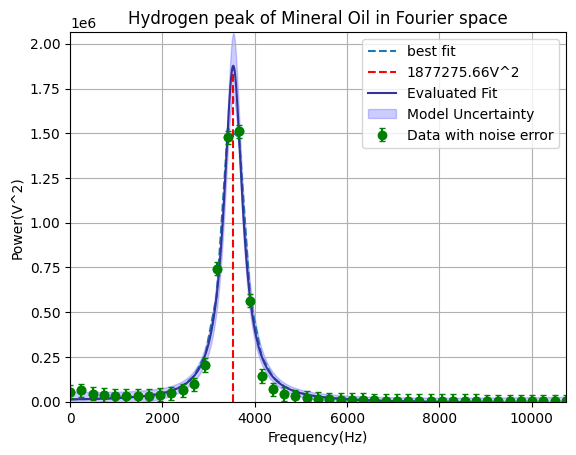

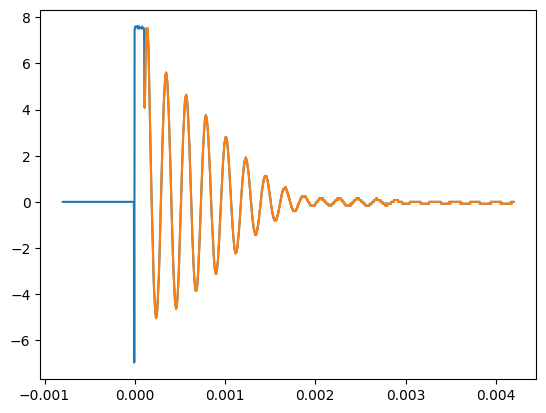

## Confidence Report:
Frequency is at 4543.982588643855 Hz


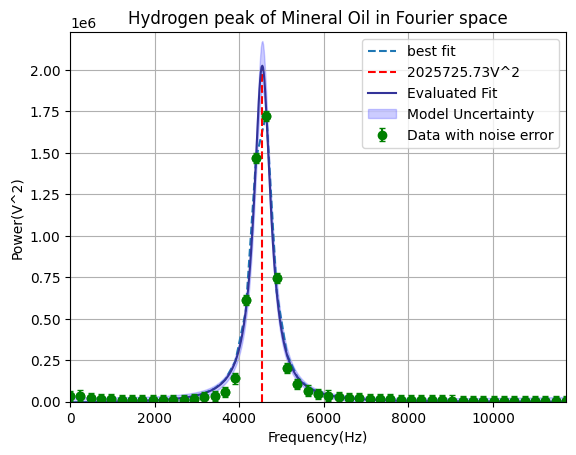

In [161]:

pulse_params= {"threshold_max":7.5, "threshold_min":6}
fft_params = {"initial_sigma": 5000, "num_points": 700, "sigma_levels": [1,2,3]}

fft_s1_2_list = get_fft_data(sample1_2[3:], sample1_2out[3:], pulse_params, fft_params, id = '_sample1_2')

## get width vs input frequency

In [162]:
print(len(fft_s1_list))

7


In [163]:
fft1_list = fft_s1_list + fft_s1_2_list

print(len(fft1_list))

11


# Sample 2

### first sample 2 

This is the raw FID plot

0.0
0       0.00
1       0.06
2       0.00
3       0.00
4       0.00
        ... 
2494    0.00
2495    0.00
2496   -0.06
2497    0.00
2498   -0.06
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



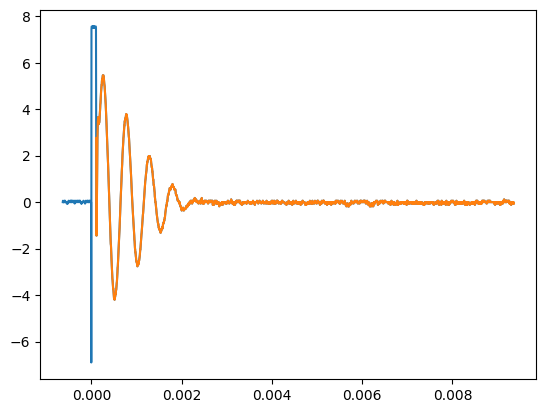

## Confidence Report:
Frequency is at 1905.361334998383 Hz
This is the raw FID plot

0.06
0       0.06
1       0.00
2       0.00
3       0.00
4       0.06
        ... 
2494   -0.12
2495   -0.06
2496   -0.06
2497    0.00
2498    0.00
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



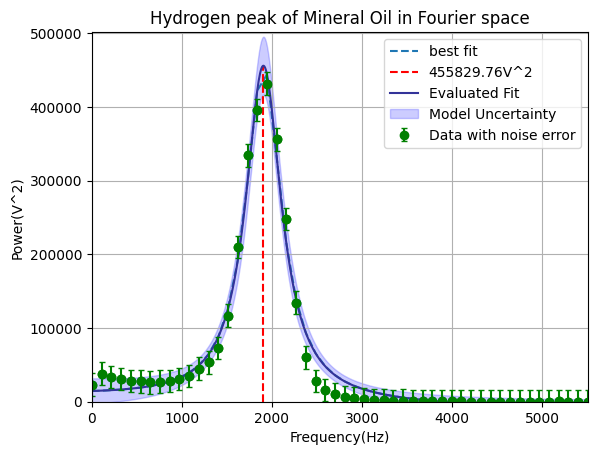

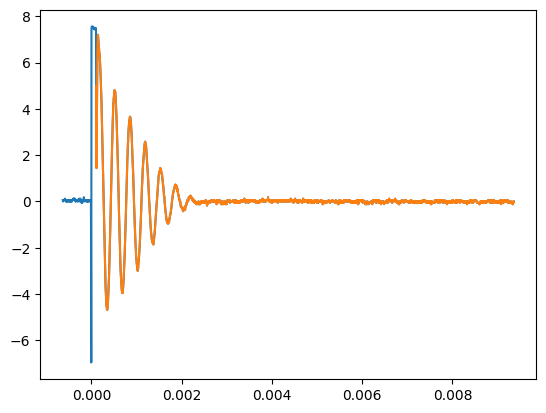

## Confidence Report:
Frequency is at 2935.531227862133 Hz
This is the raw FID plot

0.06
0       0.00
1       0.00
2       0.00
3       0.06
4       0.06
        ... 
2494    0.00
2495    0.00
2496    0.00
2497   -0.06
2498   -0.06
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



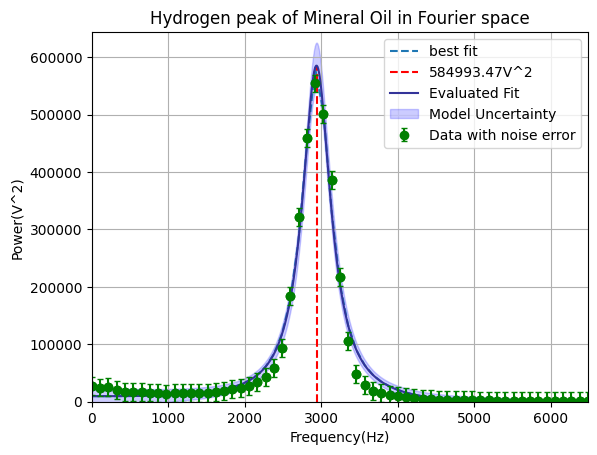

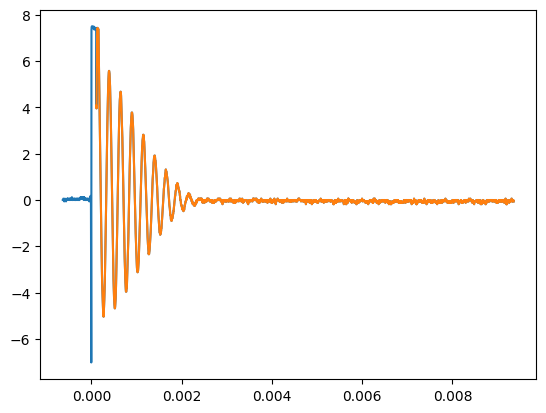

## Confidence Report:
Frequency is at 3958.8409242364633 Hz
This is the raw FID plot

0.0
0       0.00
1       0.00
2       0.00
3       0.00
4       0.00
        ... 
2494    0.00
2495    0.00
2496    0.06
2497    0.06
2498    0.06
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



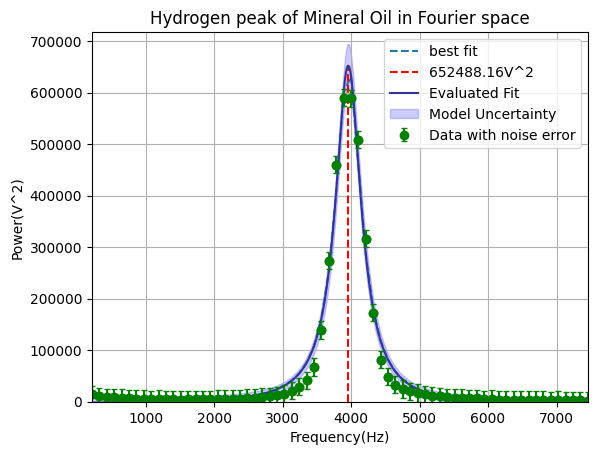

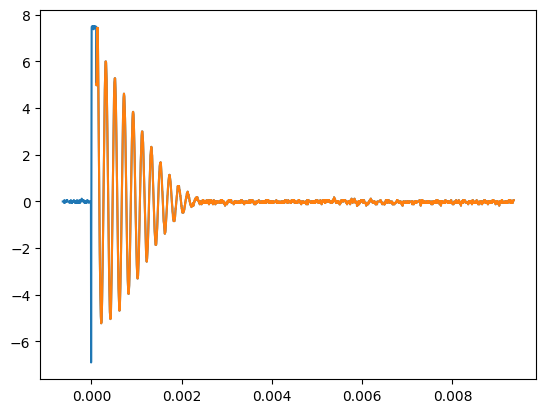

## Confidence Report:
Frequency is at 4974.289677366572 Hz
This is the raw FID plot

0.0
0       0.00
1       0.00
2       0.00
3       0.00
4       0.00
        ... 
2494   -0.06
2495   -0.06
2496    0.00
2497    0.00
2498   -0.06
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



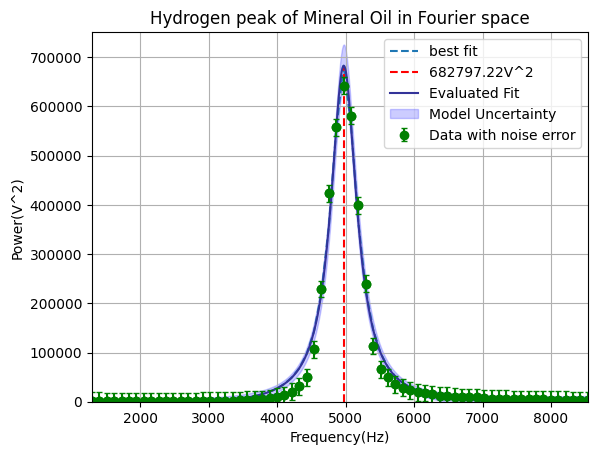

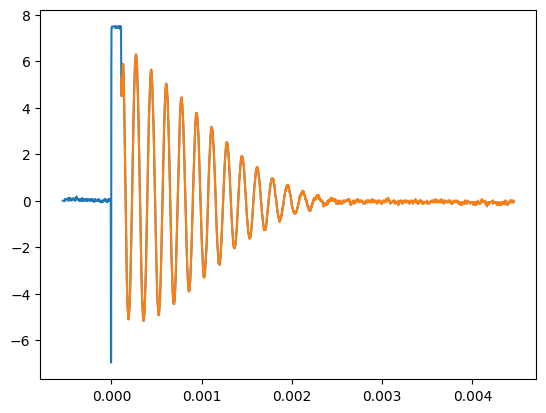

## Confidence Report:
Frequency is at 5972.986424715404 Hz
This is the raw FID plot

0.06
0       0.00
1       0.00
2       0.00
3       0.00
4       0.06
        ... 
2494   -0.06
2495    0.00
2496    0.00
2497    0.00
2498    0.00
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



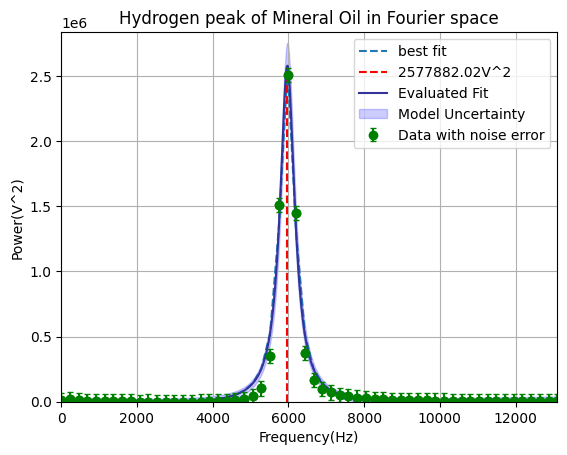

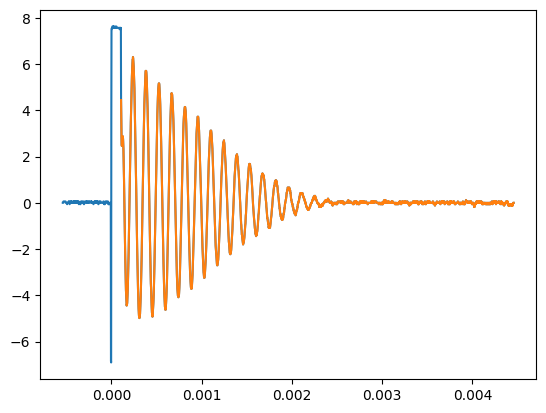

c:\Users\diyan\pNMR\pnmr_analysis\pnmr_env2\Lib\site-packages\lmfit\confidence.py:362: UserWarning: maxiter=200 reached and prob(slope=-2.0457251664907) = 0.9168784125101012 < max(sigmas)
  warn(errmsg)
c:\Users\diyan\pNMR\pnmr_analysis\pnmr_env2\Lib\site-packages\lmfit\confidence.py:362: UserWarning: maxiter=200 reached and prob(slope=2.1500988994749197) = 0.9168754366697218 < max(sigmas)
  warn(errmsg)


## Confidence Report:
Frequency is at 6979.080167186739 Hz
This is the raw FID plot

0.0
0       0.00
1       0.00
2       0.00
3       0.00
4       0.00
        ... 
2494   -0.06
2495    0.00
2496    0.00
2497    0.00
2498    0.00
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



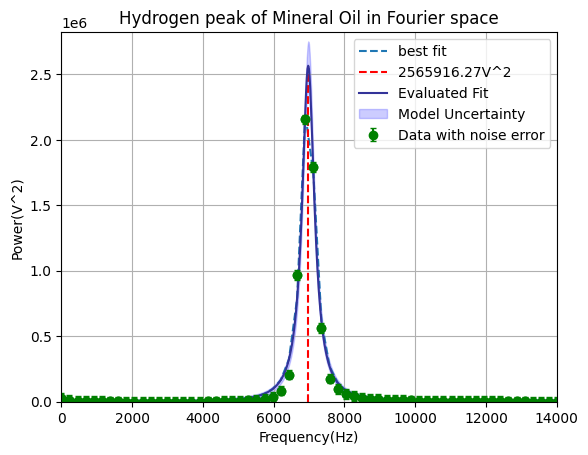

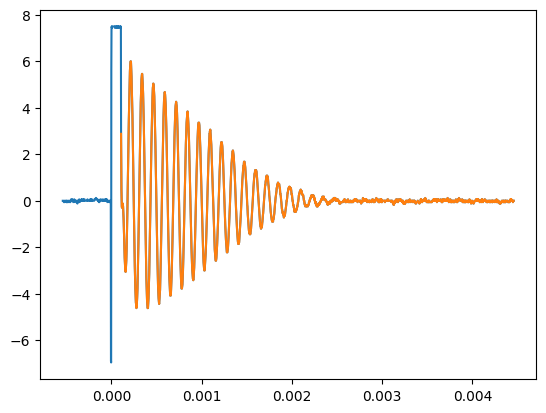

## Confidence Report:
Frequency is at 7942.738444503065 Hz


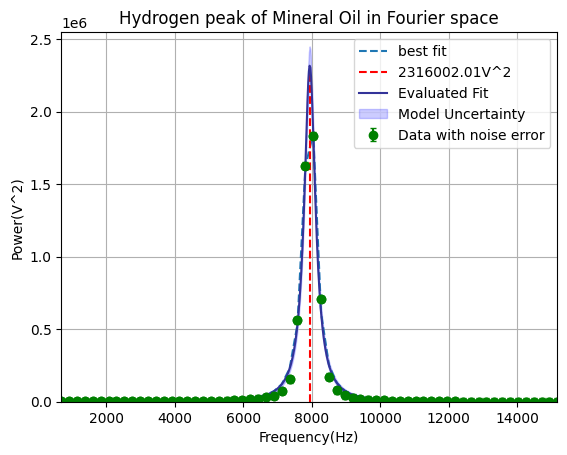

In [176]:

pulse_params= {"threshold_max":6.5, "threshold_min":6}
fft_params = {"initial_sigma": 5000, "num_points": 700, "sigma_levels": [1,2,3]}

sample2filename = "pNMR 2.26 final data FID/SAMPLE2"
sample2, sample2out = get_filenames(sample2filename, extension='.csv')

fft_s2_list = get_fft_data(sample2, sample2out, pulse_params, fft_params, id = '_sample2', plot=True)

### second sample 2

This is the raw FID plot

0.0
0       0.00
1       0.00
2       0.08
3       0.00
4       0.00
        ... 
2494   -0.08
2495   -0.08
2496   -0.08
2497   -0.08
2498   -0.08
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



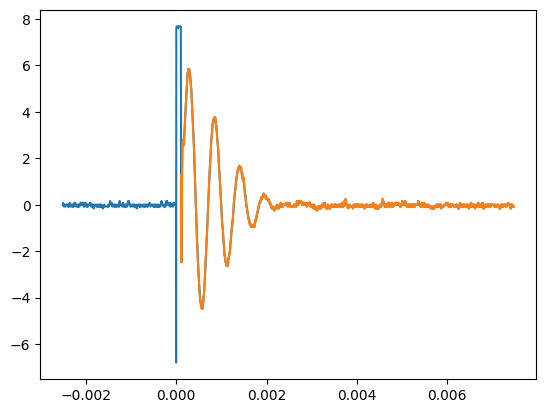

## Confidence Report:
Frequency is at 1730.0275086090714 Hz
This is the raw FID plot

0.0
0       0.00
1       0.00
2       0.00
3       0.00
4       0.00
        ... 
2494   -0.08
2495   -0.08
2496    0.00
2497   -0.08
2498   -0.08
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



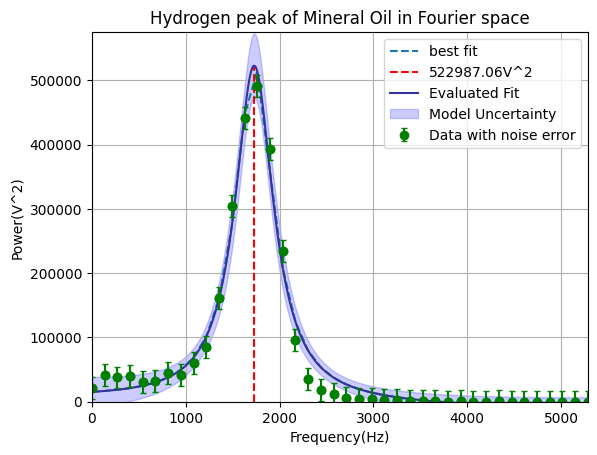

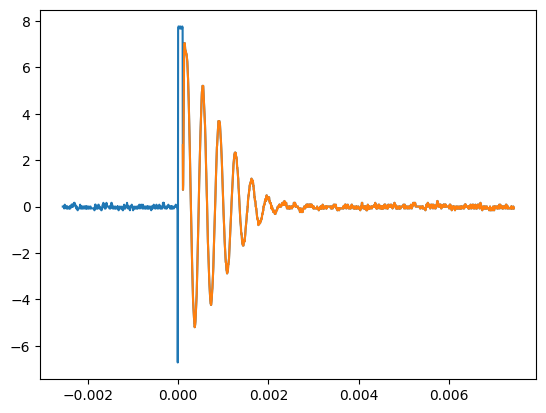

## Confidence Report:
Frequency is at 2749.7254410336745 Hz
This is the raw FID plot

0.0
0      -0.08
1       0.00
2       0.00
3       0.00
4       0.00
        ... 
2494    0.00
2495    0.00
2496    0.00
2497    0.08
2498    0.08
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



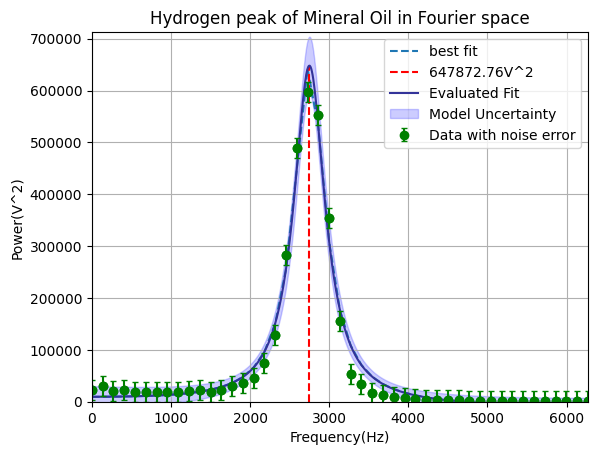

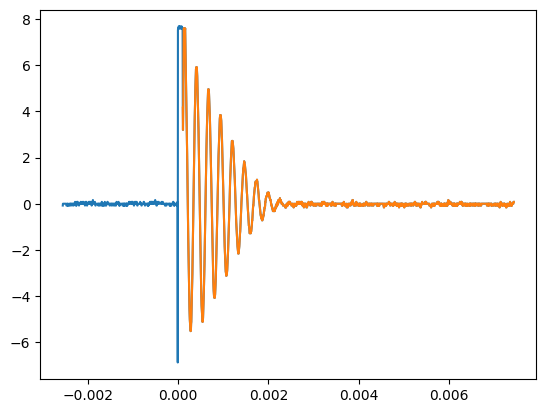

## Confidence Report:
Frequency is at 3768.8417170952393 Hz
This is the raw FID plot

0.08
0       0.00
1       0.00
2       0.00
3       0.00
4       0.08
        ... 
2494   -0.08
2495    0.00
2496    0.00
2497    0.00
2498    0.00
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



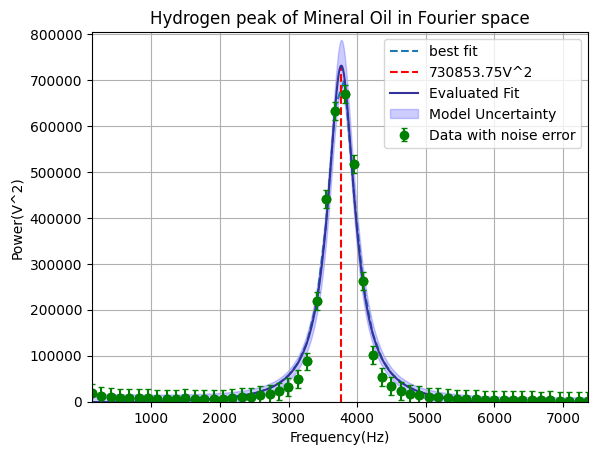

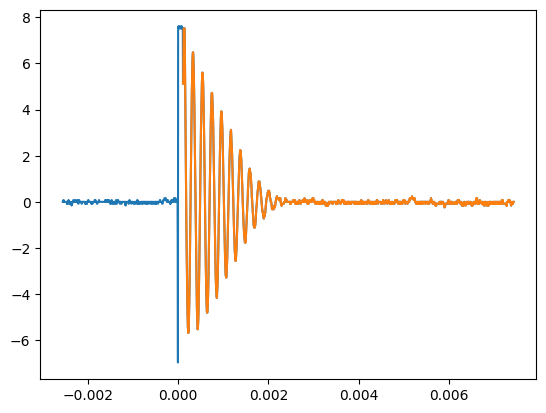

## Confidence Report:
Frequency is at 4786.367581187583 Hz


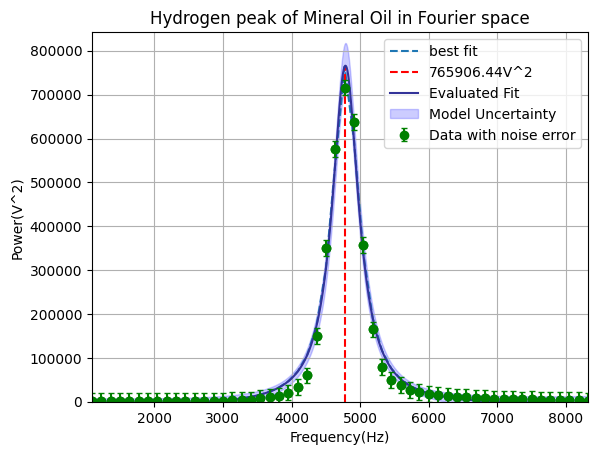

In [166]:
sample2_2filename = "2.10 Data Sample 2/FIDs"
sample2_2, sample2_2out = get_filenames(sample2_2filename, extension='.csv')

pulse_params= {"threshold_max":7.5, "threshold_min":6}
fft_params = {"initial_sigma": 5000, "num_points": 700, "sigma_levels": [1,2,3]}

fft_s2_2_list = get_fft_data(sample2_2[2:], sample2_2out[2:], pulse_params, fft_params, id = '_sample2_2')

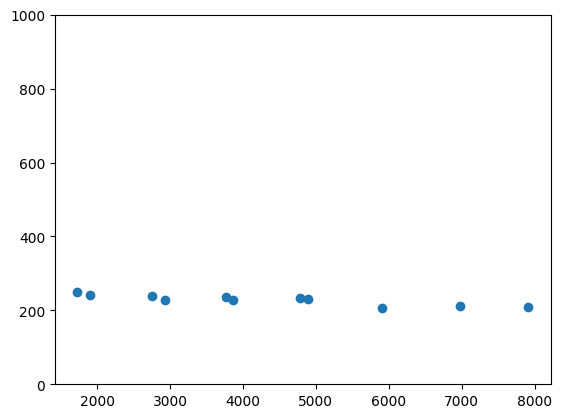

In [167]:
fft2_list = fft_s2_list + fft_s2_2_list

fft_max_freq2 = []
fft_width2 = []
 # {'max_freq':new_max_freq, 'max_power':new_maxval, 'result': result, 'eval': y_random_fit, 'ci': ci}
for fft_data in fft2_list:
    fft_max_freq2.append(fft_data['max_freq'])
    fft_width2.append(fft_data['result'].params['sigma'].value)


plt.scatter(fft_max_freq2, fft_width2)
plt.ylim(0,1000)
plt.show()

# Sample 3

This is the raw FID plot

0.04
0       0.04
1       0.08
2       0.04
3       0.04
4       0.04
        ... 
2494   -0.12
2495   -0.12
2496   -0.12
2497   -0.16
2498   -0.16
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



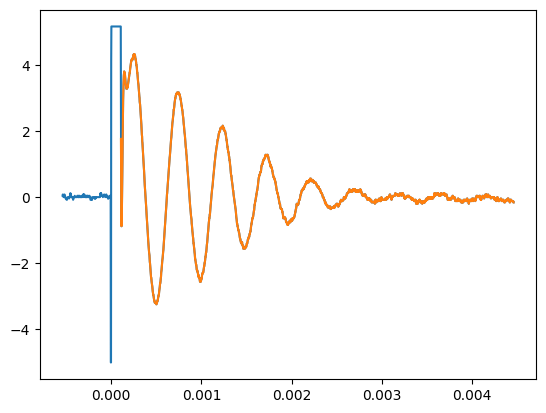

## Confidence Report:
Frequency is at 1989.7369942902199 Hz
This is the raw FID plot

0.0
0       0.04
1       0.04
2       0.04
3       0.00
4       0.00
        ... 
2494    0.04
2495    0.04
2496    0.04
2497    0.04
2498    0.08
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



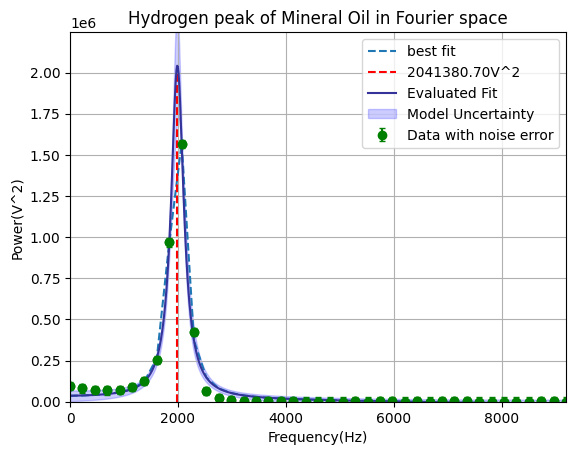

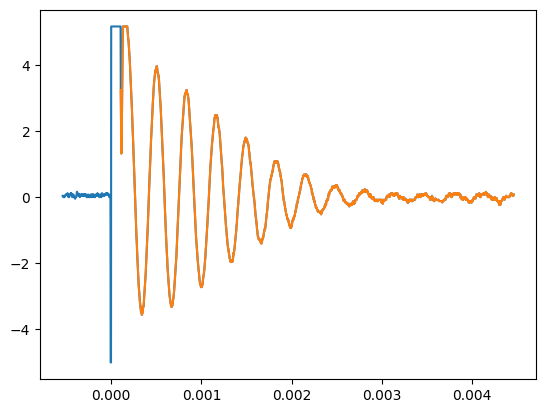

## Confidence Report:
Frequency is at 3021.7381775332697 Hz
This is the raw FID plot

0.0
0       0.08
1       0.04
2       0.04
3       0.00
4       0.00
        ... 
2494   -0.08
2495   -0.04
2496   -0.04
2497   -0.08
2498   -0.08
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



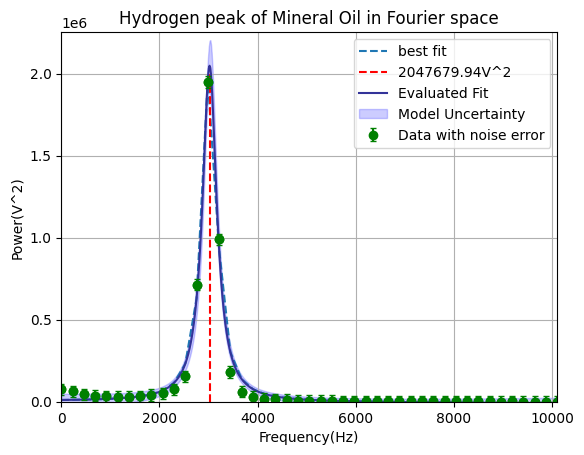

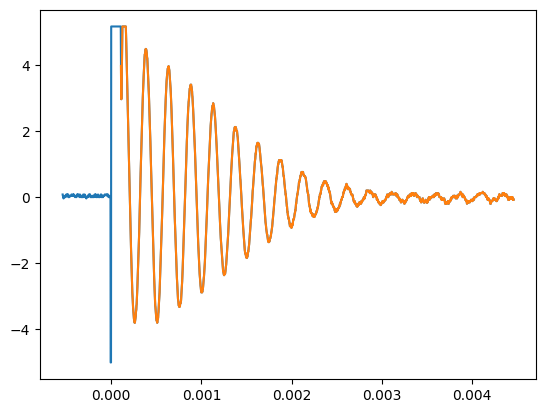

c:\Users\diyan\pNMR\pnmr_analysis\pnmr_env2\Lib\site-packages\lmfit\confidence.py:362: UserWarning: maxiter=200 reached and prob(intercept=-2518.2315141010754) = 0.35167608693252067 < max(sigmas)
  warn(errmsg)


## Confidence Report:
Frequency is at 4031.4990804287527 Hz
This is the raw FID plot

0.0
0       0.00
1       0.00
2       0.00
3       0.00
4       0.00
        ... 
2494    0.04
2495    0.08
2496    0.08
2497    0.08
2498    0.12
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



c:\Users\diyan\pNMR\pnmr_analysis\pnmr_env2\Lib\site-packages\lmfit\confidence.py:362: UserWarning: maxiter=200 reached and prob(intercept=2395.987265843741) = 0.3517169986960891 < max(sigmas)
  warn(errmsg)


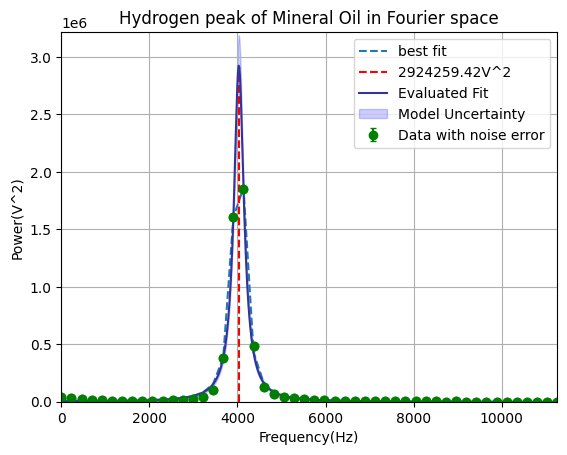

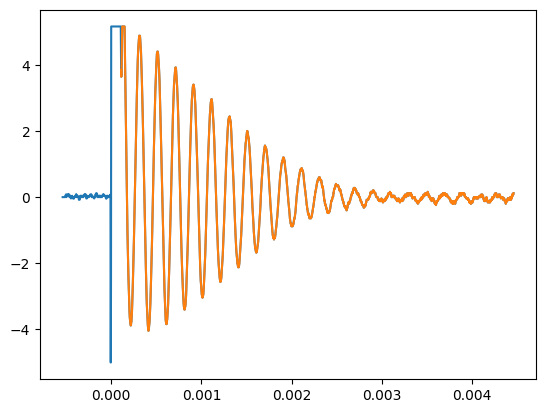

## Confidence Report:
Frequency is at 5030.825060938747 Hz
This is the raw FID plot

0.04
0       0.08
1       0.04
2       0.04
3       0.04
4       0.04
        ... 
2494    0.04
2495    0.00
2496    0.00
2497   -0.04
2498   -0.04
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



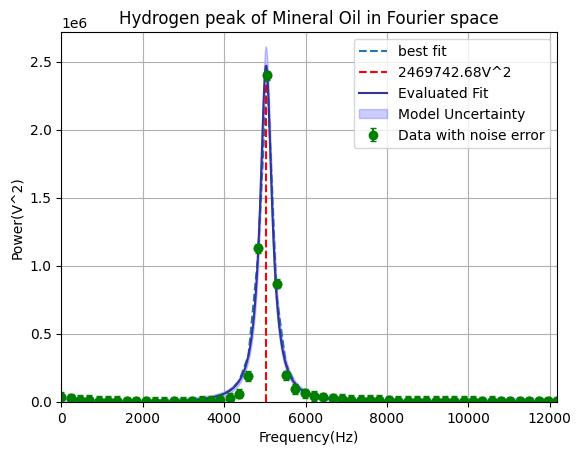

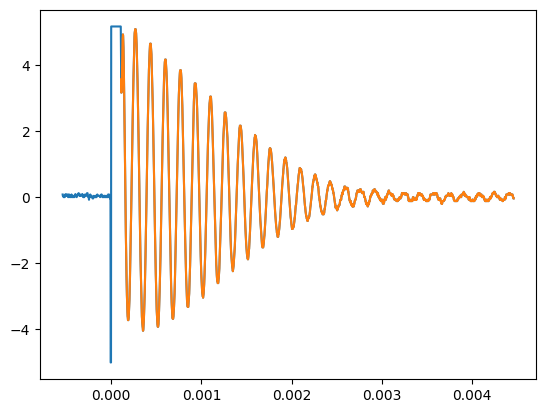

## Confidence Report:
Frequency is at 6048.4814364519925 Hz
This is the raw FID plot

0.04
0       0.08
1       0.04
2       0.00
3       0.04
4       0.04
        ... 
2494   -0.08
2495   -0.08
2496   -0.08
2497   -0.08
2498   -0.04
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



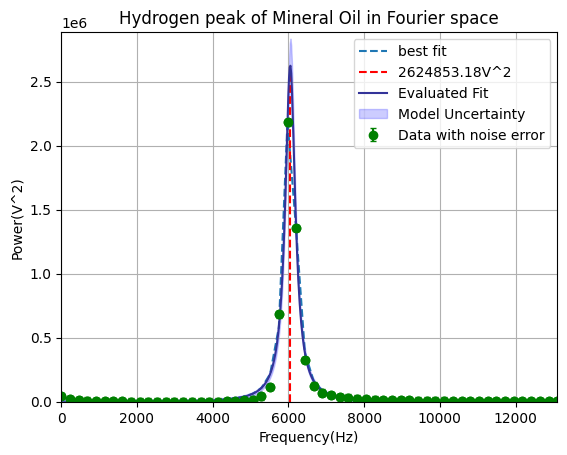

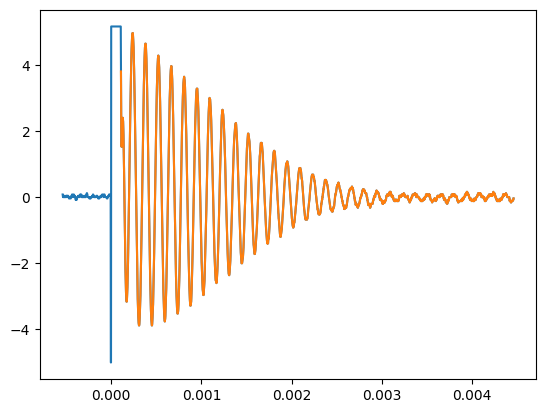

## Confidence Report:
Frequency is at 7018.24677063016 Hz
This is the raw FID plot

0.0
0       0.08
1       0.04
2       0.00
3       0.04
4       0.00
        ... 
2494    0.08
2495    0.08
2496    0.08
2497    0.08
2498    0.08
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



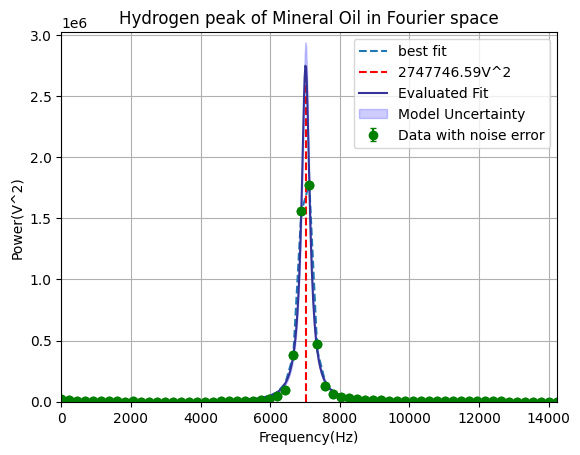

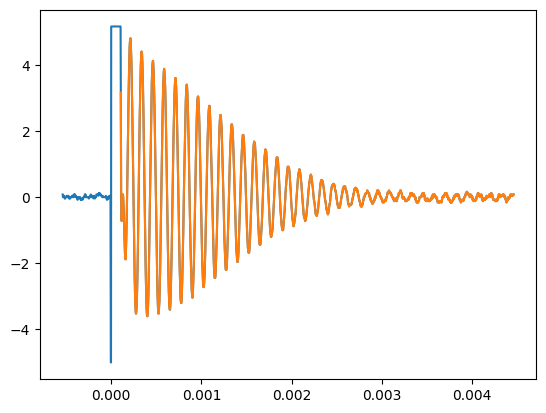

## Confidence Report:
Frequency is at 7990.210909426588 Hz


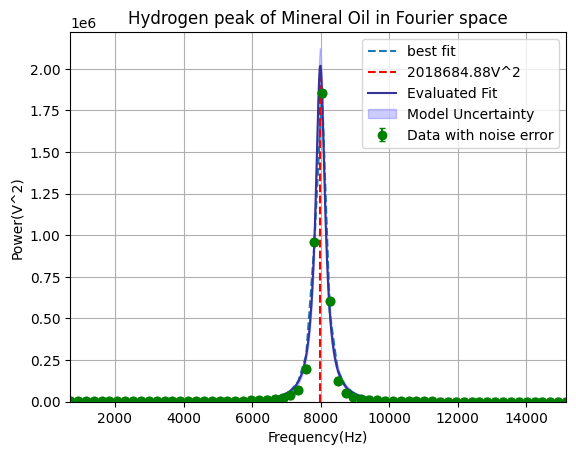

In [169]:

pulse_params= {"threshold_max":4.2, "threshold_min":4}
fft_params = {"initial_sigma": 5000, "num_points": 700, "sigma_levels": [1,2,3]}

sample2filename = "pNMR 2.26 final data FID/SAMPLE3"
sample3, sample3out = get_filenames(sample2filename, extension='.csv')

fft_s3_list = get_fft_data(sample3, sample3out, pulse_params, fft_params, id = '_sample3', plot=True)

This is the raw FID plot

0.0
0       0.04
1       0.08
2       0.04
3       0.00
4       0.00
        ... 
2494   -0.04
2495   -0.04
2496   -0.04
2497   -0.04
2498   -0.04
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



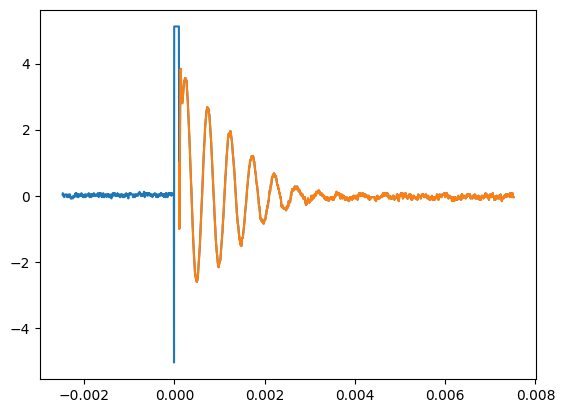

## Confidence Report:
Frequency is at 1997.1786255037757 Hz
This is the raw FID plot

0.0
0       0.00
1       0.00
2       0.00
3       0.00
4       0.00
        ... 
2494    0.00
2495    0.00
2496   -0.08
2497   -0.08
2498   -0.08
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



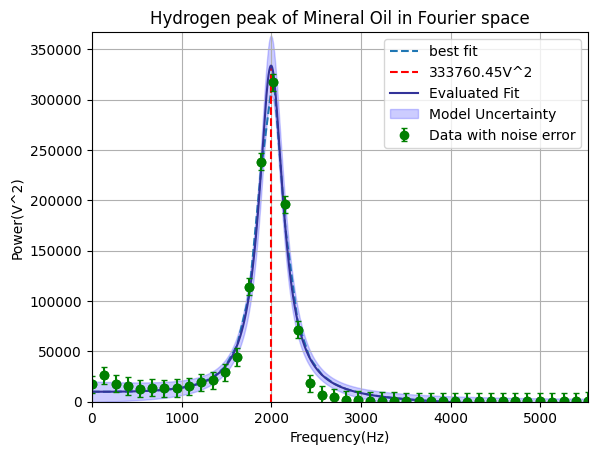

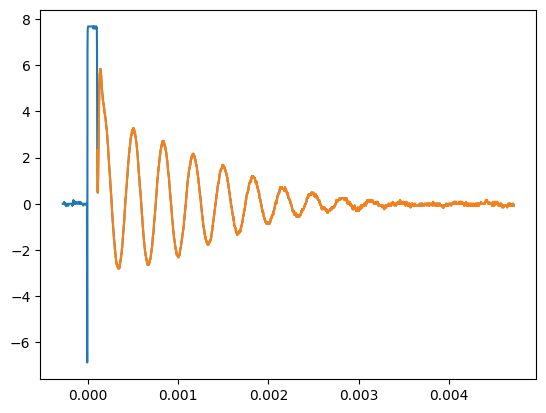

## Confidence Report:
Frequency is at 2984.2501273195267 Hz
This is the raw FID plot

0.0
0       0.08
1       0.00
2       0.00
3       0.00
4       0.00
        ... 
2494    0.00
2495    0.00
2496    0.00
2497    0.00
2498    0.00
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



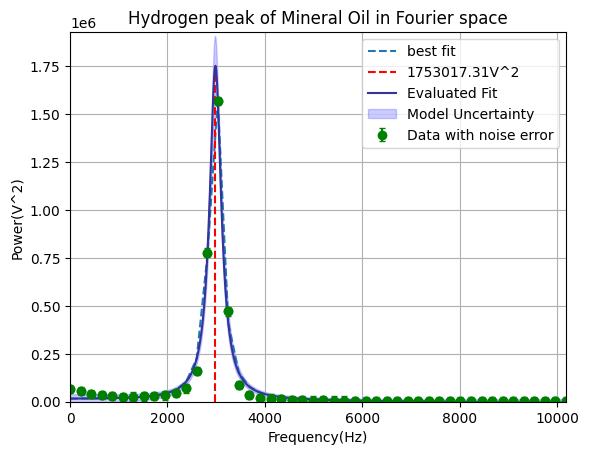

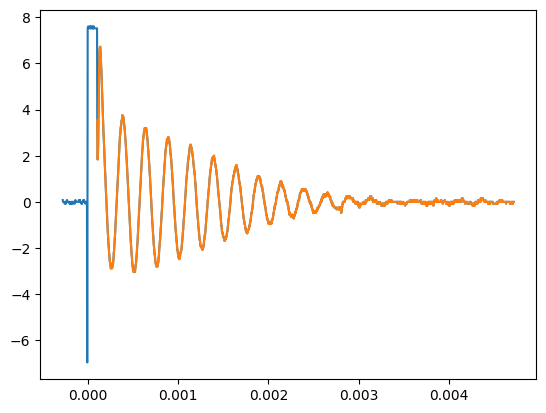

## Confidence Report:
Frequency is at 3999.1335646084026 Hz
This is the raw FID plot

0.0
0       0.00
1       0.00
2       0.00
3       0.08
4       0.00
        ... 
2494    0.08
2495    0.08
2496    0.08
2497    0.00
2498    0.00
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



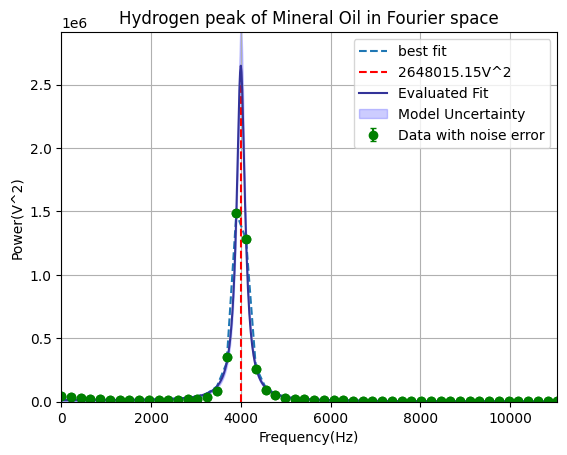

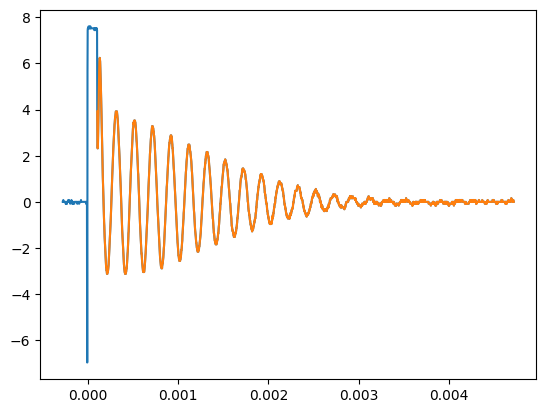

## Confidence Report:
Frequency is at 4985.499079202764 Hz


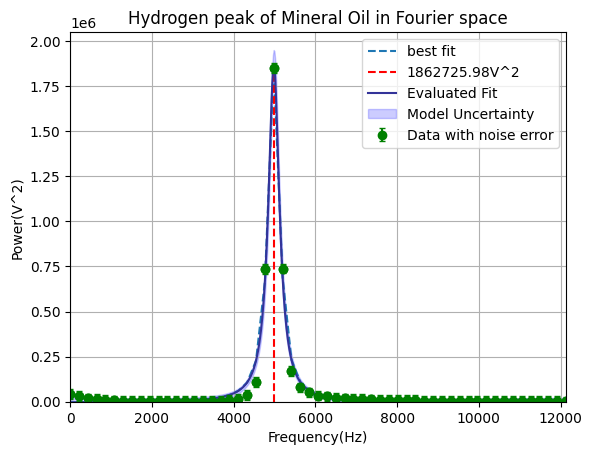

In [170]:
sample3_2filename = "2.12 Sample 3/FIDs"
sample3_2, sample3_2out = get_filenames(sample3_2filename, extension='.csv')

pulse_params= {"threshold_max":5, "threshold_min":4}
fft_params = {"initial_sigma": 5000, "num_points": 700, "sigma_levels": [1,2,3]}

fft_s3_2_list = get_fft_data(sample3_2[3:], sample3_2out[3:], pulse_params, fft_params, id = '_sample3_2')

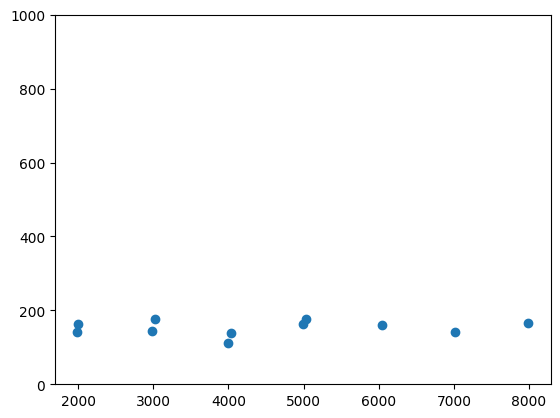

In [171]:
fft3_list = fft_s3_list + fft_s3_2_list

fft_max_freq3 = []
fft_width3 = []
 # {'max_freq':new_max_freq, 'max_power':new_maxval, 'result': result, 'eval': y_random_fit, 'ci': ci}
for fft_data in fft3_list:
    fft_max_freq3.append(fft_data['max_freq'])
    fft_width3.append(fft_data['result'].params['sigma'].value)


plt.scatter(fft_max_freq3, fft_width3)
plt.ylim(0,1000)
plt.show()

[[Model]]
    Model(constant)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 3
    # data points      = 11
    # variables        = 1
    chi-square         = 3718.46825
    reduced chi-square = 371.846825
    Akaike info crit   = 66.0548901
    Bayesian info crit = 66.4527854
    R-squared          = 1.1102e-16
[[Variables]]
    c:  153.477495 +/- 5.81414283 (3.79%) (init = 153.4775)


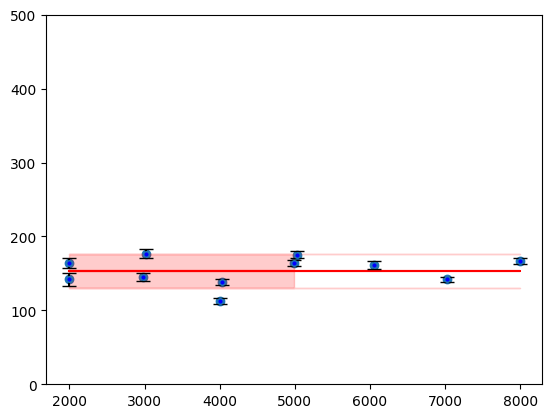

In [172]:
get_width_v_peak_freq(fft3_list)

# Width vs Volume

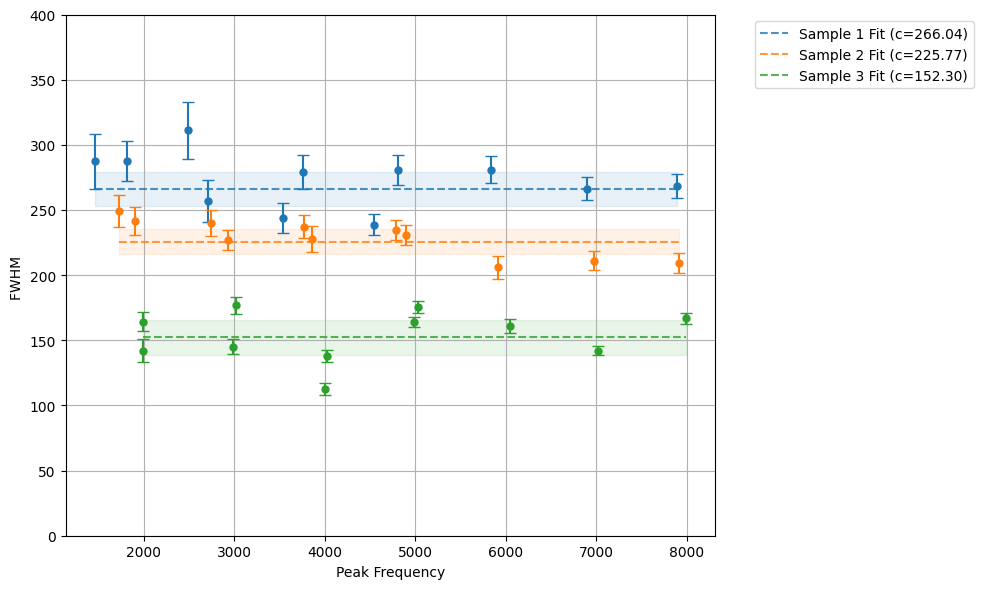

In [200]:
def get_width_v_peak_freq(fft_list, label="Dataset"):
    x = []
    y = []
    y_err = []
    # {'max_freq':new_max_freq, 'max_power':new_maxval, 'result': result, 'eval': y_random_fit, 'ci': ci}
    for fft_data in fft_list:
        # if fft_data['result'].params['sigma'].value < 1000:
        x.append(fft_data['max_freq'])
        y.append(fft_data['result'].params['sigma'].value)
        y_err.append(fft_data['result'].params['sigma'].stderr)
    
    # 2. Fit Constant Model
    model = ConstantModel()
    params = model.make_params(c=np.mean(y))
    
    # Use weights if you have error bars: weights = 1/sigma
    # (Checking for None/Zero in errors to avoid division by zero)
    weights = [1/e if e and e > 0 else 1 for e in y_err]
    result = model.fit(y, params, x=x, weights=weights)
    
    # 3. Plot Errorbars (No lines, with caps)
    line = plt.errorbar(x, y, yerr=y_err, fmt='o', capsize=4, 
                        markersize=5)
    
    # 4. Plot Fit Line & Confidence Interval
    # Get the color of the last plotted errorbar to match the fit line to the dots
    color = line[0].get_color() 
    
    # Sort X for a clean line plot
    x_sort = np.sort(x)
    best_fit = result.eval(x=x_sort)
    dely = result.eval_uncertainty(x=x_sort, sigma=2) # 95% CI
    
    plt.plot(x_sort, best_fit, color=color, linestyle='--', alpha=0.8, 
             label=f'{label} Fit (c={result.params["c"].value:.2f})')
    
    plt.fill_between(x_sort, best_fit - dely, best_fit + dely, 
                     color=color, alpha=0.1)


# --- Execution ---
plt.figure(figsize=(10, 6))
volumes = [(15.2-14.5), (21.2-18.85), (21.2-18.9) ]


ffts = [fft1_list, fft2_list, fft3_list]
for i, fft_list in enumerate(ffts):
    get_width_v_peak_freq(fft_list, label=f"Sample {i+1}")

plt.ylim(0, 400)
plt.grid()
plt.xlabel("Peak Frequency")
plt.ylabel("FWHM ")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside if crowded
plt.tight_layout()
plt.show()